<a href="https://colab.research.google.com/github/Crowk999/Pytorch_Learning/blob/main/Chapter_1(Part-1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import random

In [3]:
def plot_linear_regression(x, y, y_pred, title="Linear Regression Result"):
    plt.scatter(x, y, label="Actual Data", color="blue")
    plt.plot(x, y_pred, label="Predicted Line", color="red")

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)

    plt.show()

In [4]:
class LinearRegression(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
    self.bais = nn.Parameter(torch.randn(1, requires_grad=True, dtype = torch.float32))

  def forward(self,x:torch.Tensor) -> torch.Tensor:
    result = self.weight * x + self.bais
    return result

In [84]:
torch.manual_seed(2)
X = torch.tensor([4,5,3,5,2,3])
y = torch.tensor([1,2,3,4,5,6])
model = LinearRegression()
y_pred = model(X)
print(y_pred)
print(f"y_pred mean:{y_pred.mean()}")

tensor([1.3456, 1.7379, 0.9533, 1.7379, 0.5610, 0.9533],
       grad_fn=<AddBackward0>)
y_pred mean:1.214857578277588


In [6]:
torch.manual_seed(2) # Thus We are checcking the randomeness
model1 = LinearRegression()
model1.state_dict()

OrderedDict([('weight', tensor([0.3923])), ('bais', tensor([-0.2236]))])

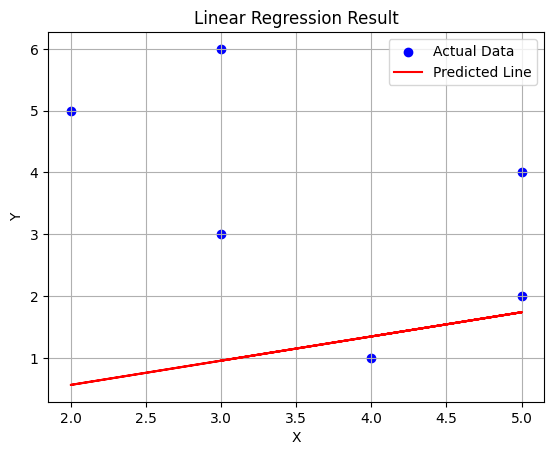

In [7]:
plot_linear_regression(X.detach().cpu().numpy(),y.detach().cpu().numpy(), y_pred.detach().cpu().numpy())

In [147]:
import torch.optim as optim
X_data = torch.tensor([1,2,3,4,5], dtype=torch.float32)
y_data = torch.tensor([1,4,9,16,25], dtype=torch.float32)
torch.manual_seed(20) # Random seed before the models
model_0 = LinearRegression()
loss_fun = nn.MSELoss()
optimizer = optim.SGD(model_0.parameters(), lr=0.001, momentum=0.9)


In [16]:
print(X_data.dtype)

torch.float32


In [159]:

for epoch in range(200):
  # Training The data
  model_0.train()

  # Predicting the data
  y_pred = model_0(X_data)

  # compite loss
  loss = loss_fun(y_pred, y_data)

  # backward pass
  optimizer.zero_grad() # makes derivative 0 for each new one / clears for old
  loss.backward() # compute new gradients

  # update weight

  optimizer.step()

  print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 1, Loss: 2.8000
Epoch 2, Loss: 2.8000
Epoch 3, Loss: 2.8000
Epoch 4, Loss: 2.8000
Epoch 5, Loss: 2.8000
Epoch 6, Loss: 2.8000
Epoch 7, Loss: 2.8000
Epoch 8, Loss: 2.8000
Epoch 9, Loss: 2.8000
Epoch 10, Loss: 2.8000
Epoch 11, Loss: 2.8000
Epoch 12, Loss: 2.8000
Epoch 13, Loss: 2.8000
Epoch 14, Loss: 2.8000
Epoch 15, Loss: 2.8000
Epoch 16, Loss: 2.8000
Epoch 17, Loss: 2.8000
Epoch 18, Loss: 2.8000
Epoch 19, Loss: 2.8000
Epoch 20, Loss: 2.8000
Epoch 21, Loss: 2.8000
Epoch 22, Loss: 2.8000
Epoch 23, Loss: 2.8000
Epoch 24, Loss: 2.8000
Epoch 25, Loss: 2.8000
Epoch 26, Loss: 2.8000
Epoch 27, Loss: 2.8000
Epoch 28, Loss: 2.8000
Epoch 29, Loss: 2.8000
Epoch 30, Loss: 2.8000
Epoch 31, Loss: 2.8000
Epoch 32, Loss: 2.8000
Epoch 33, Loss: 2.8000
Epoch 34, Loss: 2.8000
Epoch 35, Loss: 2.8000
Epoch 36, Loss: 2.8000
Epoch 37, Loss: 2.8000
Epoch 38, Loss: 2.8000
Epoch 39, Loss: 2.8000
Epoch 40, Loss: 2.8000
Epoch 41, Loss: 2.8000
Epoch 42, Loss: 2.8000
Epoch 43, Loss: 2.8000
Epoch 44, Loss: 2.80

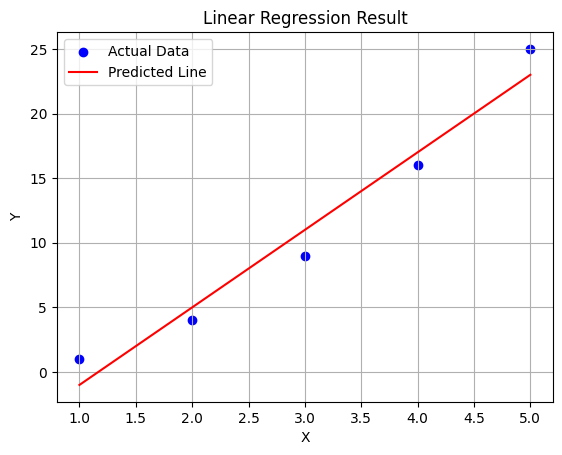

tensor([-0.9986,  5.0009, 11.0003, 16.9998, 22.9992])


In [160]:
model_0.eval()
with torch.no_grad():
  Y_pred = model_0(X_data)
plot_linear_regression(X_data.detach().cpu().numpy(),y_data.detach().cpu().numpy(), Y_pred.detach().cpu().numpy())
print(Y_pred)

In [161]:
list(model_0.parameters())

[Parameter containing:
 tensor([5.9995], requires_grad=True),
 Parameter containing:
 tensor([-6.9980], requires_grad=True)]

In [265]:
class PolynomialLinearRegression(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.weight1 = nn.Parameter(torch.randint(1,25,(1,), dtype=torch.float32))
    self.weight2 = nn.Parameter(torch.randint(1,25,(1,), dtype=torch.float32)) # for x*2 of polynomial
    self.bias = nn.Parameter(torch.randint(1,25,(1,), dtype=torch.float32))

  def forward(self, x:torch.Tensor)-> torch.Tensor:
    return self.weight1*x +self.weight2*(x**2)+self.bias

In [266]:
X_data2 = torch.tensor([1,2,3,4,5], dtype=torch.float32).unsqueeze(1)
y_data2 = torch.tensor([1,4,9,16,25], dtype=torch.float32).unsqueeze(1)
torch.manual_seed(22) # Random seed before the models
model_1 = PolynomialLinearRegression()
loss_fun = nn.L1Loss()
optimizer = optim.SGD(model_0.parameters(), lr=0.01, momentum=0.9)

In [274]:
for epoch in range(20):
  # Training The data
  model_1.train()

  # Predicting the data
  y_pred = model_1(X_data2)

  # compite loss
  loss = loss_fun(y_pred, y_data2)

  # backward pass
  optimizer.zero_grad() # makes derivative 0 for each new one / clears for old
  loss.backward() # compute new gradients

  # update weight

  optimizer.step()

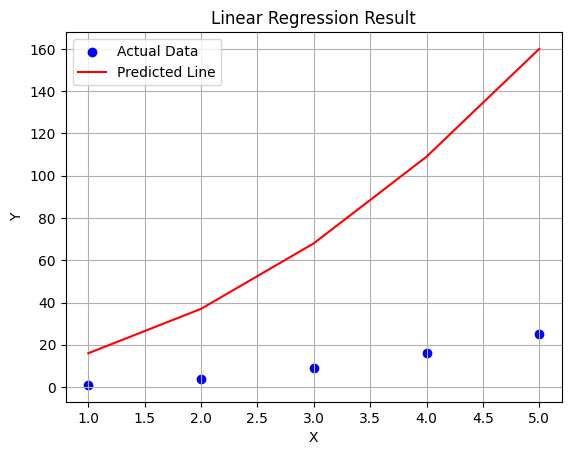

tensor([[ 16.],
        [ 37.],
        [ 68.],
        [109.],
        [160.]])


In [276]:
model_1.eval()
with torch.no_grad():
  Y_pred2 = model_1(X_data2)
plot_linear_regression(X_data2.detach().cpu().numpy(),y_data2.detach().cpu().numpy(), Y_pred2.detach().cpu().numpy())
print(Y_pred2)


In [279]:
print(model_0.state_dict())
print(model_1.state_dict())

OrderedDict({'weight1': tensor([1.0302]), 'weight2': tensor([-0.5073]), 'bias': tensor([-0.1017])})
OrderedDict({'weight1': tensor([6.]), 'weight2': tensor([5.]), 'bias': tensor([5.])})
